# 個体差によるランダム効果を含む二項ロジスティック回帰による異常検知

工業製品のロットあたりの不良品数や時間あたりの故障発生数、野球の安打数のような**計数データ**（count data）では、その発生率（成功確率）に説明変数では表せない**個体差**が発生することがあります。

例えば[ch8_5_Binomial_Logistic_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch8_5_Binomial_Logistic_Regression.ipynb)の分析では、バスケットボールのスリーポイントシュート成功率が年齢に応じて変化していました。しかし年齢以外の要素、例えば身長のような身体的特性やシュートを打った方向や距離、体調や精神状態のようなコンディションも成功率に影響を与え、これら全てを説明変数に含めることは困難です。

このような説明変数で表せない確率的な変動を**ランダム効果**（random effect）と呼びます。ランダム効果はその発生単位から、⼤きく以下の2種類に分けられます。

- 個体差によるランダム効果
- グループ差によるランダム効果（[Appendixで解説]()）

上の例で示した、「計数データにおいて、真の発生確率に説明変数で表せない個体差が発生」ケースは、個体差によるランダム効果に該当します。説明変数で表せない発生確率の変化は、以下の図に示すように、発生確率が一定の二項分布やポアソン分布よりもデータの分散が広くなる現象として観測されます。

![fig8_21](https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/images/fig8_21.png)

このように、本来想定していたモデル（上の例では二項ロジスティック回帰モデル）よりも分散が大きくなる現象を、**過分散**（overdispersion）と呼びます。計数データにおいて発生確率の個体差に由来した過分散はありふれた現象であり、二項ロジスティック回帰だけでなく、ポアソン回帰や、入出力を持たない二項分布、ポアソン分布モデルにおいてもよく発生します。これら**過分散を持つ計数データのモデリングは、以下の表のように使い分けます**。

||入出力のない計数データ（5章で使用したデータ）|入出力がある計数データ（[8.5節](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch8_5_Binomial_Logistic_Regression.ipynb)、[8.6節]()のデータ）|
|---|---|---|
|離散的な試行数$n$あたりの発生数（二項分布）|[ベータ二項分布モデル]()|**個体差によるランダム効果を含む二項ロジスティック回帰**（本notebookで解説）|
|連続的な観測区間$t$あたりの発生数（ポアソン分布）|[負の二項分布モデル]()|[個体差によるランダム効果を含むポアソン回帰]()|

ここでは個体差によるランダム効果を含む二項ロジスティック回帰による異常検知を、Python（PyMC）を用いて以下の手順で実装する方法を解説します。

- A. 変数の選択
- B. 過分散の判定
- C. モデルの学習
- D. 推論

## A. 説明変数の選択

ベイズ推定を用いた二項ロジスティック回帰モデル（[ch8_5_Binomial_Logistic_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch8_5_Binomial_Logistic_Regression.ipynb)）と同様のため、省略します。

年齢と成功率には相関があるという分析に基づき、年齢を説明変数$x$として含めることとします。

## B. 過分散の判定

個体差によるランダム効果をモデルに加えるかを判断するには、過分散が発生しているかどうかを判定する必要があります。過分散が発生していないのにランダム効果をモデルに加えてしまうと、[後述]()のようにMCMCが収束しない等の問題が発生します。逆に過分散が発生しているのにランダム効果を含めないモデルを用いると、データのばらつきを低く見積もってしまい、誤報の増大につながります（ただし、[ch8_5_Binomial_Logistic_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch8_5_Binomial_Logistic_Regression.ipynb)のように平均からのずれを検知したい場合等、モデリングの目的次第では過分散が発生していてもランダム効果を含めないこともあります）。

過分散の判定には、「実際データの分散」と「過分散がない場合の理論上の分散」の比率を表す、**分散パラメータ**（dispersion parameter）$\phi$を用います。二項ロジスティック回帰のようなGLMでは、実際のデータの分散は応答変数$Y$（実現値が$y$）の分散$Var[Y]$、理論上の分散は説明変数から線形予測子＆リンク関数で求められる確率分布の分散$V[\mu]$となります。よって分散パラメータ$\phi$は以下のように定義されます

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
\phi = \frac{Var[Y]}{V[\mu]}
\end{align}
" />

式を見ると、全ての応答変数$y^{(i)}(i=1,2,\cdots,N)$から求めた標本分散を、全ての説明変数$\boldsymbol{x}^{(i)}(i=1,2,\cdots,N)$から求められる確率分布パラメータ$\hat{\mu}^{(i)}$の標本分散で割ればいいように見えます。しかし$V[\mu]$は確率分布パラメータ$\mu$（書籍中では$\psi$とも表記）の分散を表すわけではなく、確率分布の理論上の分散（二項分布では$n^{(i)}\hat{\mu}^{(i)}(1-\hat{\mu}^{(i)})$、ポアソン分布では$\hat{\mu}^{(i)}$）を表すため、その値は試行$i$ごとに異なります。よって単純な割り算では求めることができません。

そこで統計理論から導かれた、$\phi$のデータからの不偏推定量$\hat{\phi}$を求めます。詳細は解説しませんが（[参考](https://www.sfu.ca/sasdoc/sashtml/stat/chap29/sect27.htm)）、分散パラメータ$\phi$の不偏推定量$\hat{\phi}$は、**残差逸脱度**（deviance）$D$を**自由度**$\rm{df}$で割った値

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
\hat{\phi} \simeq \frac{D}{\rm{df}}
\end{align}
" />

あるいはピアソンのカイ二乗統計量$X^2$を自由度$\rm{df}$で割った値

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
\hat{\phi} \simeq \frac{X^2}{\rm{df}}
\end{align}
" />

として求められます。残差逸脱度$D$、ピアソンのカイ二乗統計量$X^2$、自由度$\rm{df}$が具体的に何を表すのかは[後ほど補足で解説]()するので、ここではこれらの指標をPythonで求める方法を解説します。

残差逸脱度$D$やピアソンのカイ二乗統計量$X^2$を求めるためには、過分散がない場合のモデル（ランダム効果を含まない二項ロジスティック回帰やポアソン回帰）をデータから実際に学習する必要があります。この過分散判定用のモデルには、ベイズ推定を用いるよりもStatsmodelsによる最尤推定（[二項ロジスティック回帰](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/appendix/ch7_Binomial_Logisitc_Regression_Maxlikelihood.ipynb)、[ポアソン回帰](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/appendix/ch7_Poisson_Regression_Maxlikelihood.ipynb)）を用いた方が簡単です。

Statsmodelsでは、モデルの学習に用いる`fit`関数の結果として得られる`res`オブジェクトから、以下のように残差逸脱度、ピアソンのカイ二乗統計量、自由度を得られます。

- 残差逸脱度：メンバ変数`res.deviance`
- ピアソンのカイ二乗統計量：メンバ変数`res.resid_pearson`
- 自由度：メンバ変数`res.df_resid`

これらの指標を用いて、分散パラメータの推定量$\hat{\phi}$を以下のように求めます。

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

###### 学習データの読み込みと前処理######
# スリーポイントシュート成功率データ
df_train = pd.read_csv('https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/player_stats_2022.csv')
df_train = df_train[df_train['FG3A'] > 0] # 試投数0を除外
# 学習データの説明変数x、応答変数y、試行数nを別々に保持してndarray化
x_train = df_train['AGE'].to_numpy()
y_train = df_train['FG3M'].to_numpy()
n_train = df_train['FG3A'].to_numpy()

# 最尤推定による二項ロジスティック回帰モデルの学習
Y_train = np.column_stack((y_train, n_train - y_train)) # 成功数と失敗数を列に持つ2次元配列を作成
X_train_intercept = sm.add_constant(x_train) # 切片を追加
family=sm.families.Binomial() # 確率分布（二項分布）を指定
mod = sm.GLM(Y_train, X_train_intercept, family=family) # 二項ロジスティック回帰モデルを作成
res = mod.fit() # モデルの学習を実行
# 残差逸脱度、ピアソンのカイ二乗統計量、自由度を取得
deviance = res.deviance
pearson_chi2 = res.pearson_chi2
df_resid = res.df_resid
print(f'Deviance: {deviance}, Pearson Chi2: {pearson_chi2}, df_resid: {df_resid}')
# 残差逸脱度から求めた分散パラメータの推定量
phi_hat = deviance / df_resid
print(f'Estimated dispersion parameter: {phi_hat}')
# ピアソンのカイ二乗統計量から求めた分散パラメータの推定量
phi_hat_pearson = pearson_chi2 / df_resid
print(f'Estimated dispersion parameter from Pearson Chi2: {phi_hat_pearson}')

Deviance: 880.4213071158442, Pearson Chi2: 821.3260065312572, df_resid: 559
Estimated dispersion parameter: 1.5749933937671632
Estimated dispersion parameter from Pearson Chi2: 1.4692772925424995


データが過分散しているとみなすための$\hat{\phi}$のしきい値ははっきりとは定められていませんが、例えば[こちら](https://www.researchgate.net/profile/Edgar-Cagua/post/How-to-run-a-two-factorial-non-parametric-mixed-model-in-R/attachment/59d61db879197b8077979a42/AS%3A272473671569421%401441974193800/download/Mixed+effects+models+and+extensions+in+ecology+with+R.pdf)や[こちら](https://pmc.ncbi.nlm.nih.gov/articles/PMC6290908/)、[こちら](https://sites.google.com/view/ynomura/stats/overdispersion)など、多くの文献で$\hat{\phi}$が$1.5\sim2.0$よりも大きければ過分散に対するアクションを打つべきと述べられています。
他にも$D$または$X^2$を自由度$\rm{df}$のカイ二乗分布の累積分布関数と比べ、p値が有意水準未満なら過分散を疑うという検定手法もありますが、この方法はサンプルサイズが大きいほど過分散ありと判定されてしまう傾向にあるため（そもそも実データでは多かれ少なかれ過分散が発生していること多く、発生の有無よりも対処を打つほど影響が大きいかの判断の方が重要）、補助的な使用にとどめた方が良いでしょう。

今回のデータでは、残差逸脱度から求めた$\hat{\phi}$が1.57、ポアソンのカイ二乗統計量から求めた$\hat{\phi}$が1.47と、ちょうど過分散へのアクションを打つべきかどうかの境界付近の値となっています。ここは過分散ありと判断して、以下のようなランダム効果項を含む二項ロジスティック回帰の実装を進めます。

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
&r \sim \mathcal{N}(0,\sigma_r^2)  \nonumber \\
&\eta=w_1 x+w_0+r  \nonumber \\
&\rm{logit}(\mu)=\eta  \nonumber \\
&p(y \mid n, x, w_1, w_0) = Bi(n,\mu)
\end{align}
" />

このモデルを用いて選手ごとの真の成功率$\mu$の差をモデルに組み込み、能力のばらつきの範囲を超えて成功率が高い（または低い）選手を検出します。

## B. モデルの学習

ベイズ線形回帰のケースと同様、以下の4ステップに分けてMCMC（PyMC）を用いた二項ロジスティック回帰モデルの学習法（MCMCサンプリングの方法）を解説します。

- I. MCMCの実行
- II. 収束の確認
- III. 学習データからしきい値を計算
- IV. MCMC サンプルを保存

### I. MCMCの実行

まずデータの読み込みと前処理を行います。

In [2]:
# コード8.22 データの読み込みと前処理
import pandas as pd

###### 学習データの読み込みと前処理######
# スリーポイントシュート成功率データ
df_train = pd.read_csv('https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/player_stats_2022.csv')
df_train = df_train[df_train['FG3A'] > 0] # 試投数0を除外
# 学習データの説明変数x、応答変数y、試行数nを別々に保持してndarray化
x_train = df_train['AGE'].to_numpy()
y_train = df_train['FG3M'].to_numpy()
n_train = df_train['FG3A'].to_numpy()

次にモデル式を記述し、MCMCを実行します。基本的には二項ロジスティック回帰と同様の記法で、`pm.Model`クラス内にモデル式を記述します。超事前分布も通常の事前分布と同様に記述でき、ランダム効果も通常の確率分布と同様の記法で記述します。

In [3]:
# コード8.23 MCMCによるランダム効果付き二項ロジスティック回帰モデルのパラメータ推定
import pymc as pm

###### 学習ステップ1. 正常のモデルを作成する######
seed=42 # 乱数シードを指定（結果の再現性を担保）
# モデル定義用のインスタンスを作成
binomial_glmm_model = pm.Model()
# モデル式を記述
with binomial_glmm_model:
    # 説明変数xと試行数nを観測値として定義
    x = pm.Data("x", x_train, dims="record")
    n = pm.Data("n", n_train, dims="record")
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0 = pm.Normal("w_0", mu=0, sigma=100)
    w_1 = pm.Normal("w_1", mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=100) # ランダム効果の分散の超事前分布
    # ランダム効果（正規分布）
    r = pm.Normal("r", mu=0, sigma=sigma, dims="record")
    # 線形予測子（rhoのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    rho = w_0 + w_1*x + r
    # リンク関数の逆関数
    # （muのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    mu = pm.math.invlogit(rho)
    # 確率分布（二項分布）
    y = pm.Binomial("y", n=n, p=mu, observed=y_train, dims="record")
# MCMCの実行（学習）
with binomial_glmm_model:
    trace = pm.sample(random_seed=seed)
# 得られた事後分布を表示
trace.posterior

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_0, w_1, sigma, r]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<xarray.Dataset> Size: 18MB
Dimensions:  (chain: 4, draw: 1000, record: 561)
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * record   (record) int64 4kB 0 1 2 3 4 5 6 7 ... 554 555 556 557 558 559 560
Data variables:
    w_0      (chain, draw) float64 32kB -0.8125 -0.8292 ... -0.9794 -0.7971
    w_1      (chain, draw) float64 32kB 0.007332 0.008004 ... 0.01346 0.006314
    r        (chain, draw, record) float64 18MB -0.09912 0.03535 ... 0.04022
    sigma    (chain, draw) float64 32kB 0.101 0.09686 0.1064 ... 0.1327 0.131
Attributes:
    created_at:                 2025-12-31T16:36:07.599371+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.26.1
    sampling_time:              7.235698938369751
    tuning_steps:               1000

`pm.model_to_graphviz`関数を用いてグラフィカルモデルを可視化します。

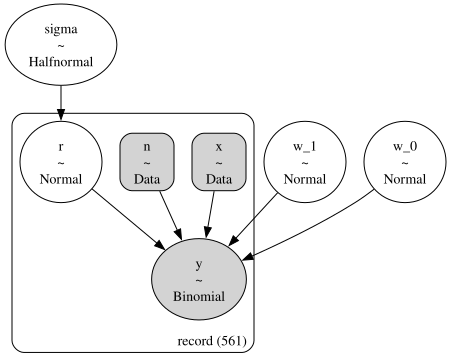

In [4]:
pm.model_to_graphviz(binomial_glmm_model)

書籍本文の図8.20と同様のモデルが定義できていることがわかります。

### II. 収束の確認

[ArviZ](https://www.arviz.org/en/latest/)の`az.plot_trace`関数で事後分布とトレースプロットをプロットし、`az.summary`関数でMCMCサンプルの概要を表示します。デフォルトではランダム効果項$r=(r^{(1)},r^{(2)},\cdots,r^{(N)})$のトレースプロットがデータ数$N$個分（今回は561個）すべて表示されてしまうため、表示対象のパラメータ名を`var_names`引数で絞り込みます。

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.122,0.012,0.099,0.143,0.001,0.000,326.319,481.291,1.010
w_0,-0.845,0.062,-0.958,-0.725,0.001,0.001,1722.056,2113.579,1.001
w_1,0.008,0.002,0.004,0.012,0.000,0.000,1767.286,2141.052,1.002
r[0],-0.022,0.088,-0.190,0.146,0.001,0.001,5034.027,3110.432,1.001
r[1],-0.005,0.121,-0.232,0.224,0.002,0.002,6055.435,2849.103,1.000
...,...,...,...,...,...,...,...,...,...
r[556],0.110,0.079,-0.046,0.253,0.001,0.001,3816.226,2413.555,1.000
r[557],-0.023,0.122,-0.251,0.207,0.002,0.002,6036.121,2807.106,1.001
r[558],0.117,0.106,-0.076,0.320,0.002,0.002,4698.638,2987.477,1.003
r[559],-0.045,0.092,-0.220,0.124,0.001,0.001,5413.800,3103.709,1.002


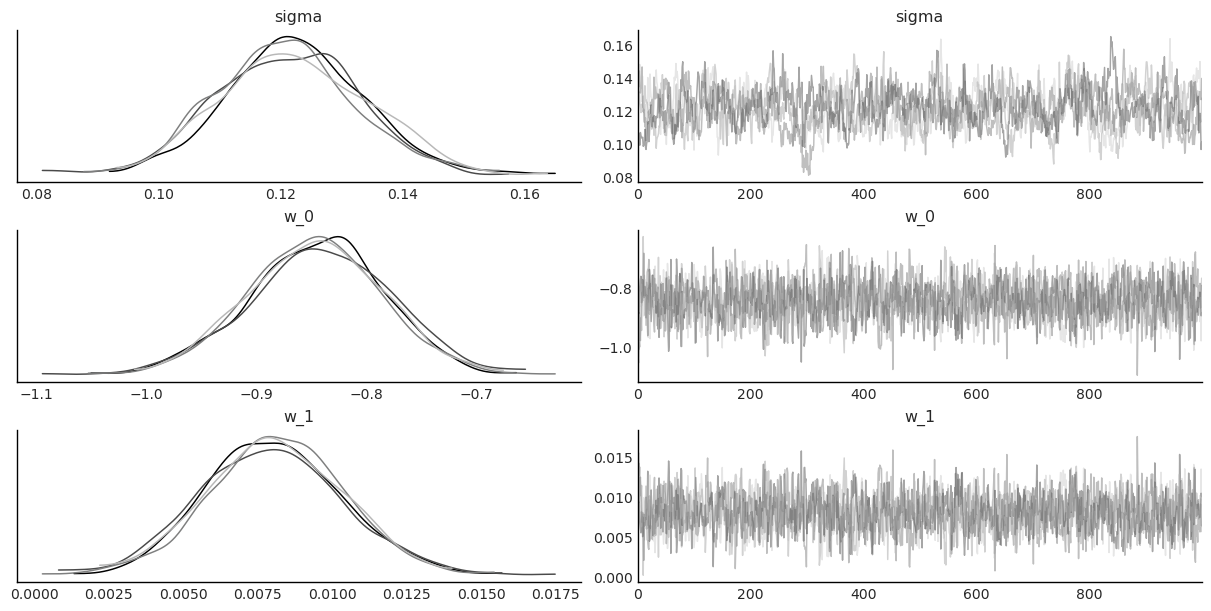

In [5]:
# コード8.25 トレースプロットとr_hatによる収束の確認
import arviz as az

# トレースプロット
az.style.use("arviz-grayscale")
az.plot_trace(trace, var_names=['sigma', 'w_0', 'w_1'],
combined=False, compact=False)
# 結果のサマリー
az.summary(trace, round_to=3, var_names=['sigma', 'w_0', 'w_1', 'r'])

パラメータ`w_0`、`w_1`、ハイパーパラメータ`sigma`ともに、各チェーンの事後分布の形状がほぼ等しくなっており、`r_hat`が1に非常に近い値となっているため、収束していると判断できそうです。一方でハイパーパラメータ`sigma`の`ess_bulk`の値がやや悪い（目安の400を少し下回っている）ですが、こちらについては後ほど対処法を解説します。

説明変数$x$（年齢`AGE`）と成功率$\mu$の事後分布の関係を確認するため、横軸に説明変数$x$をとって成功率パラメータ$\mu$の事後分布（$w_0$、$w_1$のMCMCサンプル$w_0^{(t)}$、$w_1^{(t)}$を用いて$w_1^{(t)}x+w_0^{(t)}$からMCMCサンプルを求める）をプロットしてみます。

<Axes: xlabel='AGE', ylabel='$\\mu$'>

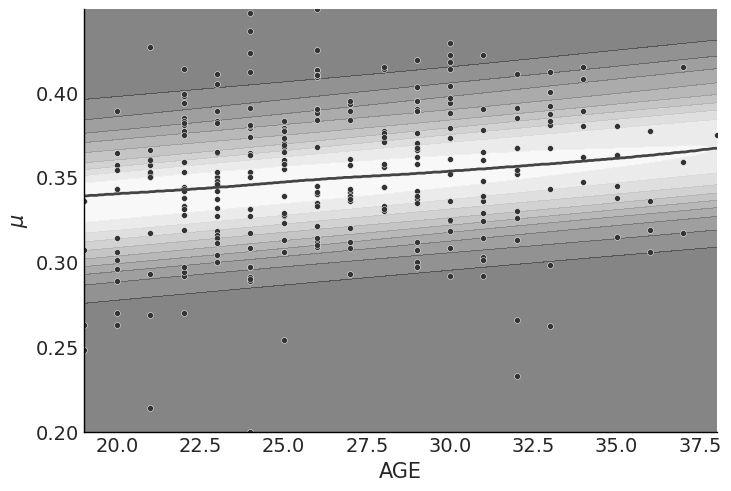

In [6]:
# 年齢xと成功率μの事後分布の関係を可視化
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import xarray as xr
from scipy import stats

# 学習データから試投数100以上のみを抽出し、xとmu範囲を決定
df_train_a100over = df_train[df_train['FG3A'] > 100]
x_min, x_max = df_train_a100over['AGE'].min(), df_train_a100over['AGE'].max()
mu_min, mu_max = df_train_a100over['FG3_PCT'].min(), df_train_a100over['FG3_PCT'].max()
# (x,μ)格子点を作成
x_grid = np.linspace(x_min, x_max, num=200)
mu_grid = np.linspace(mu_min, mu_max, num=800)
X, MU = np.meshgrid(x_grid, mu_grid)
# ランダム効果項rのMCMCサンプルを生成
sigma_poterior = trace.posterior['sigma'].to_numpy()
r_mcmc = stats.norm.rvs(
    loc=0,
    scale=sigma_poterior,
    size=sigma_poterior.shape,
    random_state=seed
)
# 線形予測子rhoの事後分布のMCMCサンプルを計算
rho_posterior = trace.posterior["w_0"] \
    + trace.posterior["w_1"]*xr.DataArray(x_grid, dims=["record"]) \
    + xr.DataArray(r_mcmc, dims=['chain', 'draw'])
# 平均パラメータmuの事後分布のMCMCサンプルを計算
mu_posterior = 1 / (1+np.exp(-rho_posterior))
# xの値ごとにmuの事後分布の確率密度関数を計算
pdf_all_grid = []
map_grid = []  # MAP推定値
for x_idx, x_i in enumerate(x_grid):
    mu_posterior_i = mu_posterior[:, :, x_idx].to_numpy()
    # KDEでmuの事後分布分布の確率密度関数を計算
    kernel = stats.gaussian_kde(mu_posterior_i.ravel())
    pdf_i = kernel(mu_grid)  # 確率密度
    map_i = mu_grid[np.argmax(pdf_i)]
    # データを保持
    pdf_all_grid.append(pdf_i)
    map_grid.append(map_i)
pdf_grid_pivot = np.array(pdf_all_grid).T
# 確率密度をプロット
plt.contourf(X, MU, pdf_grid_pivot, levels=10, cmap=cm.gray, alpha=0.5)
plt.plot(x_grid, map_grid, color='#444444', lw=2)
plt.xlabel('AGE')
plt.ylabel(r'$\mu$')
###### 学習データを散布図で描画 ######
sns.scatterplot(data=df_train_a100over,
                x='AGE', y='FG3_PCT',
                c='#333333', s=18, marker="o")

太線は事後分布のMAP推定値（最頻値）を、重ねてプロットしている散布図は学習データのうち試投数$n > 100$のものを示しています。[ランダム効果項を含まない二項ロジスティック回帰](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch8_5_Binomial_Logistic_Regression.ipynb)と比べると、ランダム効果項の作用により$\mu$の事後分布の分散が非常に⼤きくなっています。これが過分散を表しており、真の成功率の選手による個人差をモデルが表現できていることが分かります。

パラメータ`w_0`、`w_1`、ハイパーパラメータ`sigma`の事後分布の相関関係を確認するため、pairplot風に可視化してみます。

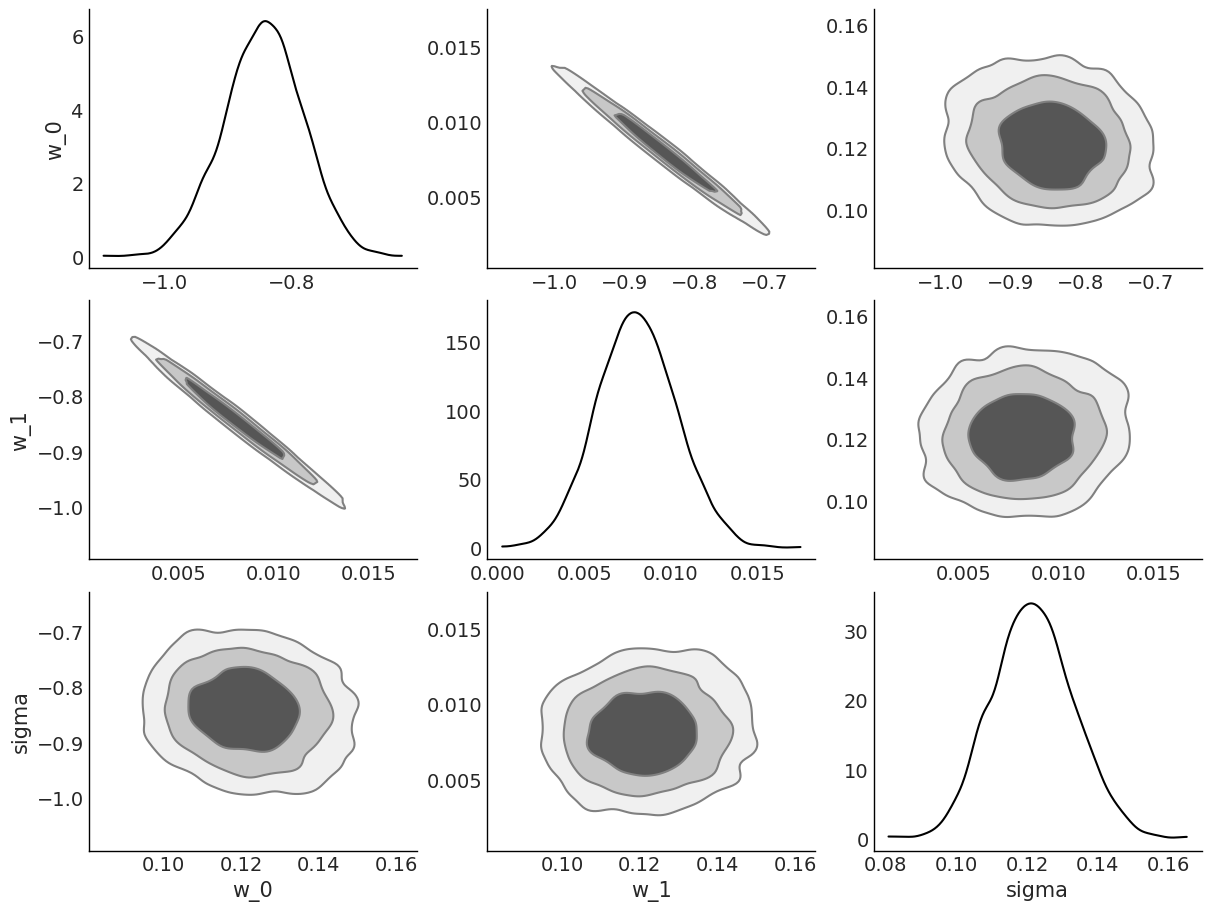

In [7]:
# パラメータの事後分布の等高線プロットによる可視化（pairplot風）
PARAM_NAMES = ['w_0', 'w_1', 'sigma']
n_params = len(PARAM_NAMES)
fig, axes = plt.subplots(n_params, n_params,
                         figsize=(n_params * 4, n_params * 3))
for i, param1 in enumerate(PARAM_NAMES):
    for j, param2 in enumerate(PARAM_NAMES):
        if i == j:
            az.plot_kde(
                az.extract(trace, var_names=param1).values,
                ax=axes[i, j]
            )
        else:
            az.plot_kde(
                az.extract(trace, var_names=param1),
                az.extract(trace, var_names=param2),
                ax=axes[i, j],
                contourf_kwargs={"cmap": "Grays"}
        )
        if j == 0:
            axes[i, j].set_ylabel(param1)
        if i == len(PARAM_NAMES) - 1:
            axes[i, j].set_xlabel(param2)

パラメータ`w_0`と`w_1`に強い相関があることが分かります。二項ロジスティック回帰の場合と同様、このような事後分布の相関関係はパラメータの識別可能性が低いことを示唆する場合があるため、後ほどデータの中央化による対処法を紹介します。トレースプロットや`r_hat`、`ess_bulk`のような収束性を表す指標が良好なため、現時点では特に対処はせず実装を進めます。

### III. 学習データからしきい値を計算

ランダム効果を含む二項ロジスティック回帰では、しきい値の算出に推論データの説明変数$\boldsymbol{x}$および試行数$n$が必要となるため、学習段階ではしきい値を決定できません。推論フェーズであらためて算出します。

### IV. 学習で求めたMCMCサンプルを保存

学習で求めたMCMCサンプルをnetCDF形式で保存し、推論フェーズで再利用できるようにします。

In [8]:
# コード8.26 学習で求めたMCMC サンプルの保存
filepath_mcmc = './8_8_2_mcmc_samples.nc' # モデルの保存ファイル名
trace.posterior.to_netcdf(filepath_mcmc)

## C. 推論

推論フェーズでは、学習フェーズで求めたパラメータ$w_1,w_0$、ハイパーパラメータ$\sigma$のMCMCサンプル、および推論データの試行数$n$、説明変数$\boldsymbol{x}$、応答変数$y$を用いて、以下の推論手順にしたがい異常判定を実施します。

- 学習で得たパラメータ$w_1,w_0$のMCMCサンプルと推論データの説明変数$x$、試行数$n$から、モンテカルロ積分により予測分布のMCMCサンプルを得る
- 予測分布のMCMCサンプルの分位点とターゲットとする誤報率に基づき、応答変数yの上下のしきい値を求める
- 推論データの応答変数$y$が、このしきい値の範囲外にあれば異常あり、範囲内にあれば異常なしと判定する

まずは以下のように、学習時に保存したMCMCサンプルを読み込みます。

In [9]:
# コード8.27 学習時に保存したMCMCサンプルの読み込み
import xarray as xr

# MCMCサンプルを読み込み
filepath_mcmc = './8_8_2_mcmc_samples.nc'
posterior_mcmc = xr.load_dataset(filepath_mcmc)

次に以下のように、推論データ（2023年度のデータ）の読み込みと前処理を実施します。

In [10]:
# コード8.28 推論データの読み込みと前処理
# スリーポイントシュート成功率データ
df_inference = pd.read_csv('https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/player_stats_2023.csv')
df_inference = df_inference[df_inference['FG3A'] > 0] # 試投数0を除外
# 学習データの説明変数x、応答変数y、試行数nを別々に保持してndarray化
x_inference = df_inference['AGE'].to_numpy()
y_inference = df_inference['FG3M'].to_numpy()
n_inference = df_inference['FG3A'].to_numpy()

ここから以下のように、予測分布のMCMCサンプルの算出としきい値判定を実施します。

In [11]:
# コード8.29 予測分布のMCMCサンプルの算出としきい値による異常判定
import numpy as np
from scipy import stats

seed=42 # 乱数シードを指定（結果の再現性を担保）
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
# ランダム効果項rのMCMCサンプルをレコード数分だけ生成
sigma_poterior = posterior_mcmc['sigma'].to_numpy()
r_mcmc = []
for i in range(len(x_inference)):
    r_mcmc.append(stats.norm.rvs(
        loc=0,
        scale=sigma_poterior,
        size=sigma_poterior.shape,
        random_state=seed
    ))
r_mcmc = np.array(r_mcmc)
# 線形予測子rhoの事後分布のMCMCサンプルを計算
x_inference_xr = xr.DataArray(x_inference, dims=["record"])
rho_posterior = posterior_mcmc["w_0"] \
    + posterior_mcmc["w_1"]*x_inference_xr \
    + xr.DataArray(r_mcmc, dims=['record', 'chain', 'draw'])
# 平均パラメータmuの事後分布のMCMCサンプルを計算
mu_posterior = 1 / (1+np.exp(-rho_posterior))
# 推論データ(y, n, x)から予測分布のMCMCサンプルと異常度を計算
predictions = []
# データごとに予測分布を計算
for i, (y, n) in enumerate(zip(y_inference, n_inference)):
    mu_posterior_i = mu_posterior[:, :, i].to_numpy()
    # muとnから予測分布のMCMCサンプルを計算
    posterior_predictive = stats.binom.rvs(
        n=n,
        p=mu_posterior_i,
        size=mu_posterior_i.shape,
        random_state=seed
    )
    # 下側しきい値（MCMCサンプルとターゲットとする誤報率から計算）
    th_lower = np.quantile(posterior_predictive, TARGET_FP_RATE/2)
    # 上側しきい値（MCMCサンプルとターゲットとする誤報率から計算）
    th_upper = np.quantile(posterior_predictive, 1 - TARGET_FP_RATE/2)
    # しきい値判定
    pred = np.where((y < th_lower) | (y > th_upper), 'anomaly', 'normal')
    predictions.append(str(pred))

判定のしきい値を超えた選手の一覧を成功率が高い順にリストアップします。

In [12]:
# コード8.30 異常判定のしきい値を超えた選手のリストアップ
# 推論結果を表示（しきい値を超えた選手）
df_inference['3P%'] = y_inference / n_inference # 成功率
df_inference['prediction'] = predictions
print(df_inference[df_inference['prediction'] == 'anomaly'][
      ['PLAYER_ID', 'AGE', '3P%', 'FG3A', 'FG3M']].sort_values(
      '3P%', ascending=False).reset_index(drop=True))

   PLAYER_ID   AGE       3P%  FG3A  FG3M
0    1628379  27.0  0.494424   269   133


検出された`PLAYER_ID`が1628379 の選手は、2022年シーズンの選手のばらつきから推測される偶然の範囲を超えて（発生率0.0027以下）、スリーポイントシュート成功率が高いと言えるでしょう。
ランダム効果を含まない通常の二項ロジスティック回帰モデルと比べ、検出される選手数が減りました。これは過分散を考慮してモデリングしたことにより、成功数（応答変数$y$）のばらつきが大きくなったため（二項分布由来のばらつきにランダム効果が加わる）、このばらつきの範囲を超える成功数を記録することがより難しくなることに起因します。

ランダム効果によりばらつきが大きくなったことを確認するため、異常と判定される範囲を推論データと重ねて可視化してみます。

Plotting image 1/4


/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_27917/1656885103.py:71: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(x=n_filtered, y=mu_filtered, hue=predictions_filtered,


Plotting image 2/4
Plotting image 3/4


/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_27917/1656885103.py:71: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(x=n_filtered, y=mu_filtered, hue=predictions_filtered,


Plotting image 4/4


/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_27917/1656885103.py:71: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(x=n_filtered, y=mu_filtered, hue=predictions_filtered,
/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_27917/1656885103.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


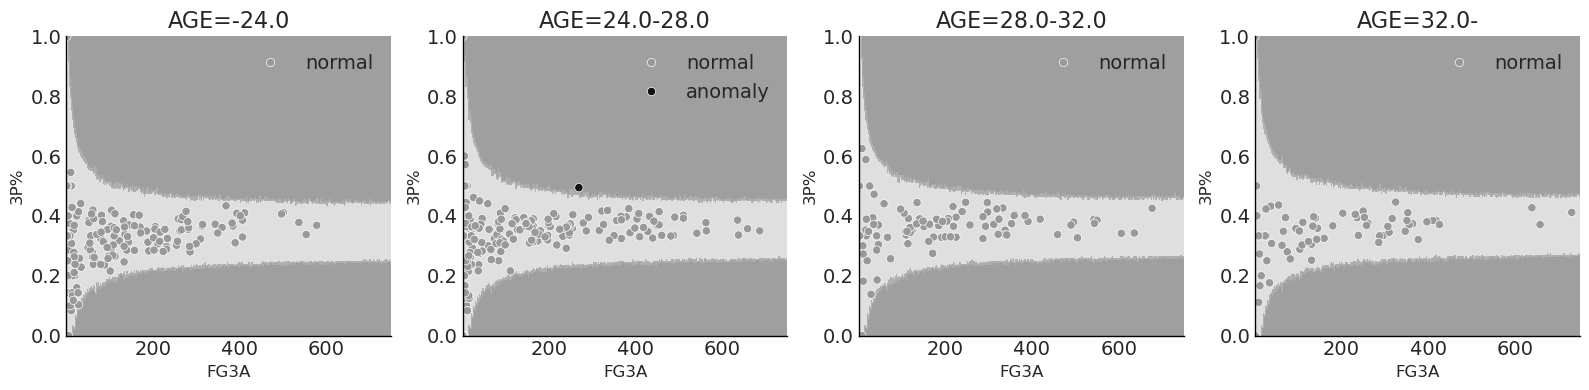

In [13]:
# 正常と異常の境界をプロット
import sys
from sklearn.neighbors import NearestNeighbors

X_BY = 4
X_CENTER = 28
N_IMAGES = 4
x_borders = [X_CENTER - X_BY*(N_IMAGES/2-1) + X_BY*i for i in range(N_IMAGES-1)]

# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=1, ncols=N_IMAGES, figsize=(N_IMAGES * 4, 4))

for img_idx in range(N_IMAGES):
    print(f'Plotting image {img_idx+1}/{N_IMAGES}')
    # 画像内のxの範囲内の最小値、最大値、代表値を抽出
    x_min = -sys.float_info.max if img_idx == 0 else x_borders[img_idx-1]
    x_max = sys.float_info.max if img_idx == len(x_borders) else x_borders[img_idx]
    x_rep = x_borders[0] - X_BY/2 if img_idx == 0 else x_borders[img_idx-1] + X_BY/2
    # 画像内のxの範囲内の推論データを抽出
    x_mask = np.where((x_min <= x_inference) & (x_inference < x_max))
    n_filtered = n_inference[x_mask]
    y_filtered = y_inference[x_mask]
    mu_filtered = y_filtered / n_filtered
    predictions_filtered = np.array(predictions)[x_mask]
    # (n,y)格子点を作成（厳密には格子ではなくnに依存してyの要素数が変わる）
    n_list = np.arange(1, 751)
    y_grid = [np.arange(n+1) for n in n_list]
    # (n,mu)格子点を作成
    mu_list = np.linspace(0, 1, 200)
    N, MU = np.meshgrid(n_list, mu_list)
    # ランダム効果に従うMCMCサンプルを生成
    sigma_poterior = posterior_mcmc['sigma'].to_numpy()
    r_mcmc = stats.norm.rvs(
        loc=0,
        scale=sigma_poterior,
        size=sigma_poterior.shape,
        random_state=seed
    )
    # 線形予測子rhoの事後分布のMCMCサンプルを計算（xは代表値x_repを使用）
    rho_posterior = posterior_mcmc["w_0"] + posterior_mcmc["w_1"]*x_rep \
        + xr.DataArray(r_mcmc, dims=['chain', 'draw'])
    # 平均パラメータmuの事後分布のMCMCサンプルを計算
    mu_posterior = 1 / (1+np.exp(-rho_posterior))
    # nの値ごとに予測分布を計算
    pred_all_grid = []
    for n_idx, (n_i, ys_i) in enumerate(zip(n_list, y_grid)):
        # 予測分布のMCMCサンプルを計算
        posterior_predictive = stats.binom.rvs(
            n=n_i,
            p=mu_posterior,
            size=mu_posterior.shape,
            random_state=seed
        )
        # 下側しきい値（MCMCサンプルとターゲットとする誤報率から計算）
        th_lower = np.quantile(posterior_predictive, TARGET_FP_RATE/2)
        # 上側しきい値（MCMCサンプルとターゲットとする誤報率から計算）
        th_upper = np.quantile(posterior_predictive, 1 - TARGET_FP_RATE/2)
        # しきい値判定
        pred = np.where((ys_i < th_lower) | (ys_i > th_upper), 0, 1)
        # muのグリッドに判定を近似的に割り当てる（k近傍法）
        knn = NearestNeighbors(n_neighbors=1, algorithm='auto', metric='minkowski')
        knn.fit(ys_i.reshape(-1, 1)/n_i)
        distances, indices = knn.kneighbors(mu_list.reshape(-1, 1))
        pred_neighbor = [pred[i[0]] for i in indices]
        pred_all_grid.append(pred_neighbor)
    pred_all_pivot = np.array(pred_all_grid).T
    # 正常と異常の境界をプロット
    axes[img_idx].contourf(N, MU, pred_all_pivot, levels=1, cmap=cm.gray, alpha=0.5)

    ###### 推論データを散布図で描画 ######
    sns.scatterplot(x=n_filtered, y=mu_filtered, hue=predictions_filtered,
                    palette=['#999999', '#111111'], ax=axes[img_idx])
    axes[img_idx].set_xlabel('FG3A', fontsize=12)
    axes[img_idx].set_ylabel('3P%', fontsize=12)
    x_min_label = '' if img_idx == 0 else str(round(x_min, 2))
    x_max_label = '' if img_idx == len(x_borders) else str(round(x_max, 2))
    axes[img_idx].set_title(f'AGE={x_min_label}-{x_max_label}')
# グラフを表示
plt.tight_layout()
plt.show()

ランダム効果項を含まない二項ロジスティック回帰と比べると、ランダム効果項のばらつきが加わって予測分布の分散が⼤きくなり、正常判定の範囲が広がったことがわかります。

このようにランダム効果を加えることで、選手の能力の個人差（データ上は過分散として観測される）を考慮した異常検知を実現できました。

## Tips：収束性が悪い場合の対処（$\sigma_r$の事前分布調整、データの中心化、非中心化パラメーター化）

ランダム効果項を含む二項ロジスティック回帰では、収束性を低下させる要因として以下の現象がよく発生します。

1. $\sigma_r$の事前分布の分散設定が不適切
2. パラメータの識別可能性が低い（ランダム効果項を含まない二項ロジスティック回帰と同メカニズム）
3. ニールの漏斗（Neal's Funnel）

`r_hat`、`ess_bulk`のような収束性を表す指標が悪い場合、上記の現象の発生の有無を確認した上で、それぞれ以下のような対処を打つ必要があります。

1. $\sigma_r$の事前分布分散の適切な設定
2. **データの中心化**（centering）
3. **非中心化パラメーター化**（non-centered parameterization）

今回のデータとモデルでは、ハイパーパラメータ`sigma`の`ess_bulk`の値がやや悪かったため、その改善を題材としてそれぞれ解説します。

### 1. $\sigma_r$の事前分布分散の適切な設定

ここまで使用してきたモデルでは、ランダム効果項の標準偏差パラメータ$\sigma_r$の事前分布として、ベイズ線形回帰の標準偏差パラメータ$\sigma$と同じ`pm.HalfNormal("sigma", sigma=100)`を用いてきました。しかしベイズ線形回帰では応答変数と$\sigma$のスケールが等しかったのに対し、ランダム効果項を含む二項ロジスティック回帰では$\sigma_r$と応答変数の間にシグモイド関数による変換が加わるため、`sigma=100`という値は分散が極端に大きくなってしまいます。大きな分散は無情報を作り出すという意味では良く見えますが、ランダム効果項において極端に大きな分散は、後述のニールの漏斗等の問題を引き起こしやすくなります。よって無情報に近い状態を保ちつつ、問題を起こすほど大きくならないような、適切な`sigma`の値を設定する必要があります。

例えば[StanのGitHub Wiki](https://github.com/stan-dev/stan/wiki/Prior-Choice-Recommendations#prior-for-scale-parameters-in-hierarchical-models)では`sigma=1`が推奨値として挙げられているなど、多くの文献で概ね1〜2の範囲が`sigma`の推奨値となっています（あるいは`Half-Normal`ではなく`Half-Cauchy`が推奨されている場合もあります）。

ここでは以下のように、`pm.HalfNormal("sigma", sigma=1.0)`に設定してMCMCを実行し直してみます。

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_0, w_1, sigma, r]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.122,0.011,0.102,0.144,0.001,0.000,342.289,886.022,1.014
w_0,-0.841,0.062,-0.964,-0.729,0.001,0.001,1966.909,2206.678,1.003
w_1,0.008,0.002,0.004,0.012,0.000,0.000,1950.491,2184.544,1.002
r[0],-0.025,0.088,-0.191,0.143,0.001,0.002,4818.345,2875.813,1.000
r[1],-0.006,0.121,-0.251,0.210,0.001,0.002,6918.571,2818.210,1.001
...,...,...,...,...,...,...,...,...,...
r[556],0.110,0.076,-0.029,0.257,0.001,0.001,6019.419,2986.106,1.002
r[557],-0.023,0.122,-0.246,0.209,0.002,0.002,6113.987,2795.004,1.001
r[558],0.117,0.110,-0.077,0.342,0.002,0.002,4846.362,2837.235,1.001
r[559],-0.044,0.093,-0.218,0.138,0.001,0.002,6324.369,2947.721,1.000


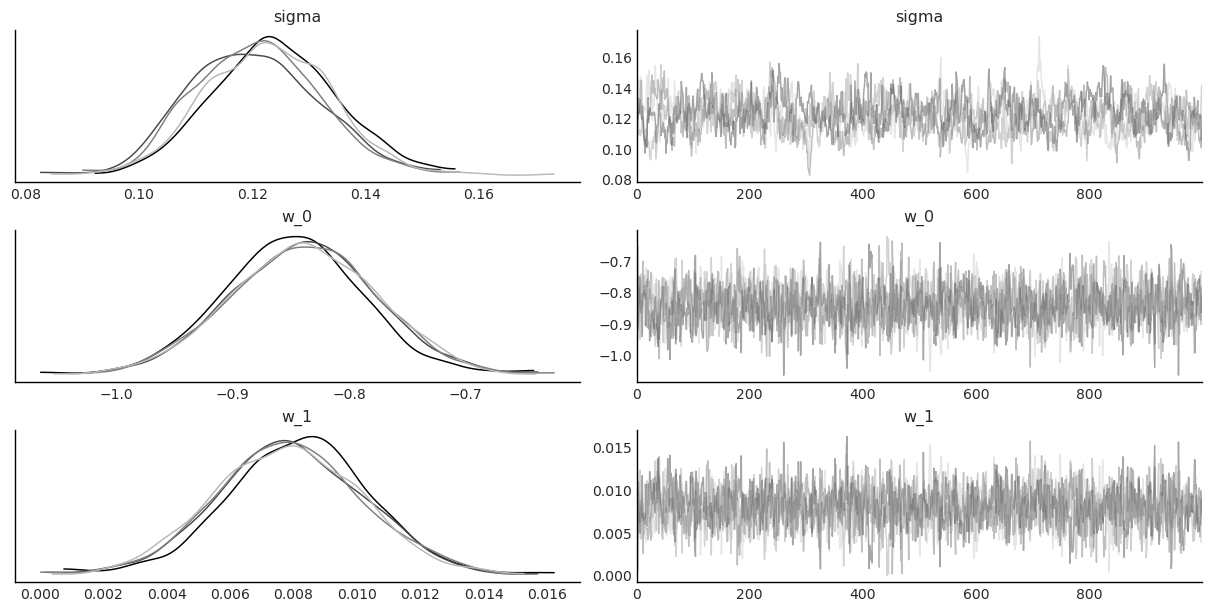

In [14]:
# sigmaの事前分布を`pm.HalfNormal("sigma", sigma=1.0)`に設定してMCMCを再実行
import pymc as pm
import arviz as az

binomial_glmm_model = pm.Model()
# モデル式を記述
with binomial_glmm_model:
    # 説明変数xと試行数nを観測値として定義
    x = pm.Data("x", x_train, dims="record")
    n = pm.Data("n", n_train, dims="record")
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0 = pm.Normal("w_0", mu=0, sigma=100)
    w_1 = pm.Normal("w_1", mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=1.0) # ランダム効果の分散の超事前分布
    # ランダム効果（正規分布）
    r = pm.Normal("r", mu=0, sigma=sigma, dims="record")
    # 線形予測子（rhoのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    rho = w_0 + w_1*x + r
    # リンク関数の逆関数
    # （muのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    mu = pm.math.invlogit(rho)
    # 確率分布（二項分布）
    y = pm.Binomial("y", n=n, p=mu, observed=y_train, dims="record")
# MCMCの実行（学習）
with binomial_glmm_model:
    trace = pm.sample(random_seed=seed)
# 得られた事後分布を表示
trace.posterior

# トレースプロット
az.style.use("arviz-grayscale")
az.plot_trace(trace, combined=False, compact=False, var_names=['sigma', 'w_0', 'w_1'])
# 各パラメータのMCMCサンプルの概要を表示
az.summary(trace, round_to=3, var_names=['sigma', 'w_0', 'w_1', 'r'])

各変数の`ess_bulk`がやや改善しているように見えますが、それほど大きな向上ではありません。特に`sigma`の`ess_bulk`は依然として目安である400を下回っており、値が悪い主要因は別にあるとみなせそうです。

### 2. データの中心化によるパラメータの識別可能性向上

先ほどの可視化では、パラメータの事後分布に強い相関関係が認められたため、パラメータの識別可能性が低いことが疑われます。

識別可能性を向上させるための対処としては、ランダム効果なしの二項ロジスティック回帰と同様に、データの中心化が有効です。以下のようにデータを中心化してからMCMCを実行します。

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_0_c, w_1_c, sigma, r]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.122,0.011,0.102,0.143,0.001,0.000,318.711,1004.793,1.007
w_0_c,-0.634,0.011,-0.654,-0.614,0.000,0.000,1816.142,2587.092,1.001
w_1_c,0.008,0.002,0.004,0.012,0.000,0.000,3118.755,3219.661,1.002
r[0],-0.025,0.087,-0.199,0.131,0.001,0.002,6742.122,2689.078,1.001
r[1],-0.004,0.121,-0.236,0.232,0.001,0.002,7909.962,2627.166,1.000
...,...,...,...,...,...,...,...,...,...
r[556],0.110,0.073,-0.026,0.246,0.001,0.001,6656.813,2812.620,1.002
r[557],-0.026,0.124,-0.245,0.217,0.001,0.002,9145.205,2768.122,1.002
r[558],0.117,0.110,-0.079,0.333,0.001,0.002,6302.196,2921.153,1.001
r[559],-0.045,0.091,-0.225,0.113,0.001,0.002,6618.529,3016.024,1.000


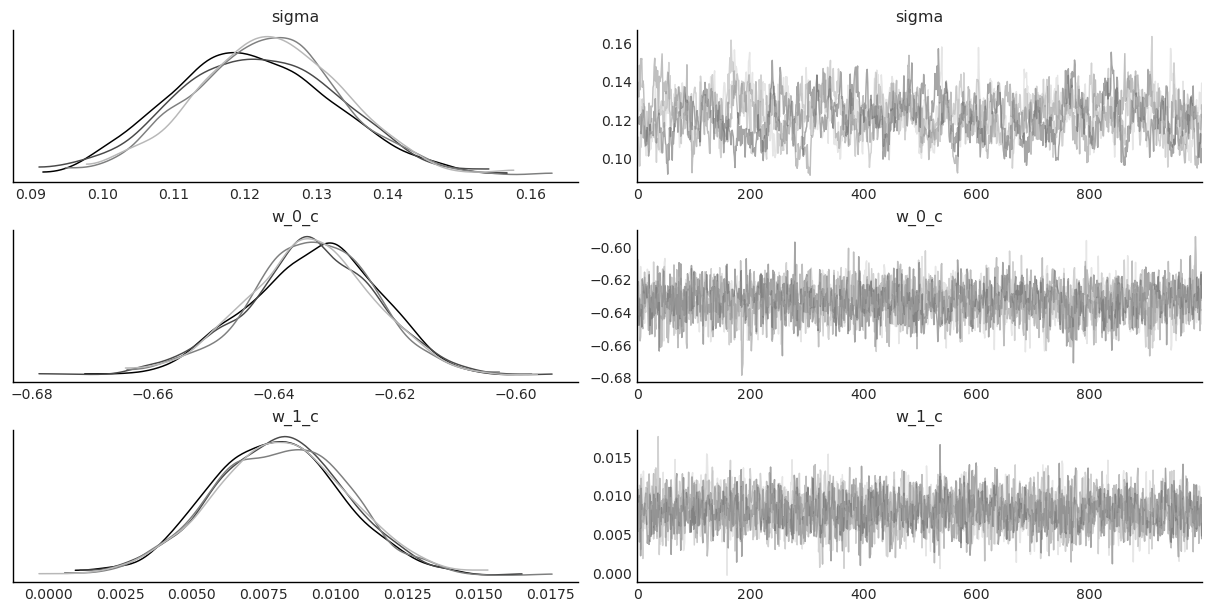

In [15]:
# データを中心化してMCMCを再実行
import pymc as pm
import arviz as az

# データの標本平均
x_mean = x_train.mean()

binomial_glmm_model = pm.Model()
# モデル式を記述
with binomial_glmm_model:
    # 中心化した説明変数x_cと試行数nを観測値として定義
    x_c = pm.Data("x_c", x_train - x_mean, dims="record")
    n = pm.Data("n", n_train, dims="record")
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0_c = pm.Normal("w_0_c", mu=0, sigma=100)  # 中心化後のパラメータであることを明示的に示すため名前変更
    w_1_c = pm.Normal("w_1_c", mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=1.0) # ランダム効果の分散の超事前分布
    # ランダム効果（正規分布）
    r = pm.Normal("r", mu=0, sigma=sigma, dims="record")
    # 線形予測子（rhoのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    rho = w_0_c + w_1_c*x_c + r
    # リンク関数の逆関数
    # （muのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    mu = pm.math.invlogit(rho)
    # 確率分布（二項分布）
    y = pm.Binomial("y", n=n, p=mu, observed=y_train, dims="record")
# MCMCの実行（学習）
with binomial_glmm_model:
    trace = pm.sample(random_seed=seed)
# 得られた事後分布を表示
trace.posterior

# トレースプロット
az.style.use("arviz-grayscale")
az.plot_trace(trace, combined=False, compact=False, var_names=["sigma", "w_0_c", "w_1_c"])
# 各パラメータのMCMCサンプルの概要を表示
az.summary(trace, round_to=3, var_names=["sigma", "w_0_c", "w_1_c", 'r'])

中心化する前と比べてサンプリング速度が速くなり、また`w_1_c`に関する`r_hat`や`ess_bulk`のような収束性を表す指標が向上しています。

一方で、本来改善したかった`sigma`の`r_hat`や`ess_bulk`はほとんど変化していません。これは`sigma`の収束性の悪さが事後分布の相関関係（パラメータの識別可能性）とは別の現象に起因していることを示唆しています。こちらについては後ほど非中心化パラメータ化による対処を解説します。

パラメータの事後分布の相関関係を2次元KDEで可視化してみます。

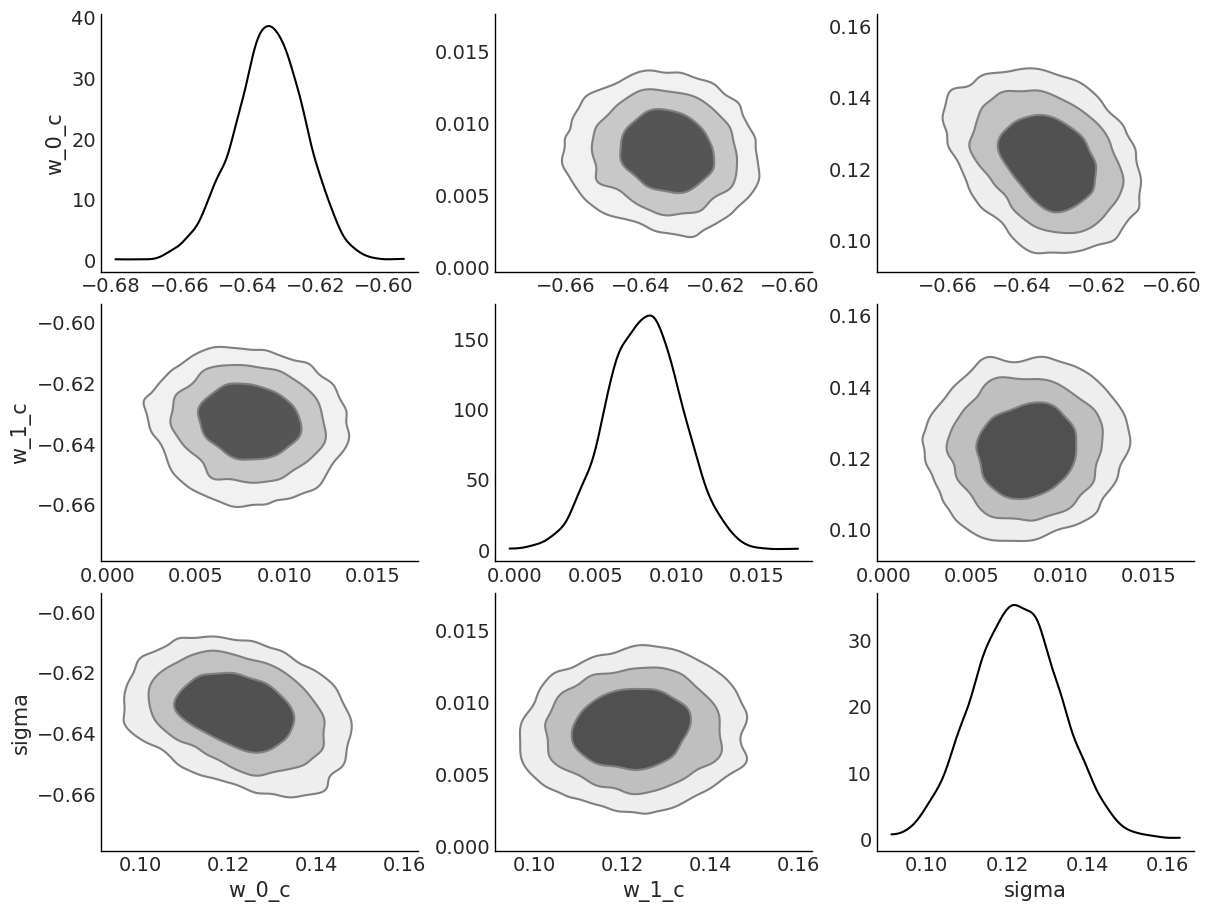

In [16]:
# パラメータの事後分布の等高線プロットによる可視化（pairplot風）
PARAM_NAMES = ['w_0_c', 'w_1_c', 'sigma']
n_params = len(PARAM_NAMES)
fig, axes = plt.subplots(n_params, n_params,
                         figsize=(n_params * 4, n_params * 3))
for i, param1 in enumerate(PARAM_NAMES):
    for j, param2 in enumerate(PARAM_NAMES):
        if i == j:
            az.plot_kde(
                az.extract(trace, var_names=param1).values,
                ax=axes[i, j]
            )
        else:
            az.plot_kde(
                az.extract(trace, var_names=param1),
                az.extract(trace, var_names=param2),
                ax=axes[i, j],
                contourf_kwargs={"cmap": "Grays"}
        )
        if j == 0:
            axes[i, j].set_ylabel(param1)
        if i == len(PARAM_NAMES) - 1:
            axes[i, j].set_xlabel(param2)

パラメータ`w_0`と`w_1`の相関関係が解消されたことが分かります。

### 3. ニールの漏斗と非中心化パラメーター化

ランダム効果を含む二項ロジスティック回帰では、ここまで詳細に可視化や分析を行なった`w_0`、`w_1`、`sigma`以外にも、ランダム効果項`r`（$r^{(1)},r^{(2)},\cdots,r^{(N)}$）がMCMCでの推定対象となります。
このとき、`r`の生成に用いる正規分布の標準偏差が`sigma`であることを考慮すると、`r`の各要素（例えば$r^{(1)}$）と`sigma`（$\sigma_r$）の事後分布の同時分布は、$\sigma_r$を縦軸に取った場合、$(\sigma_r, r^{(1)})=(0,0)$の点が先端の下に尖った形状となります。

このような先端が尖った形状の事後分布は、MCMCのサンプリングの効率が悪くなります。その代表例が**ニールの漏斗**（Neal's funnel）であり、その詳細については[松浦 健太郎, 2016](https://www.kyoritsu-pub.co.jp/book/b10003786.html)）を参照してください。今回の先端の尖り方は直線的なため、指数関数が掛かることでより先端が尖るニールの漏斗と比べると、悪影響としては弱くなりそうです。とはいえサンプリング効率は低下する可能性が高いため、その代表的な対処法である**非中心化パラメーター化**（non-centered parameterization）を実施します。

非中心化パラメータ化とは、$r\sim \mathcal{N}(\mu, \sigma)$のようにある平均$\mu$とスケール$\sigma$を持つ正規分布から生成されるパラメータ$r$を、$\epsilon=\mathcal{N}(\mu, \sigma)$と$r=\mu + \sigma \epsilon$に分けて定義する方法です。これにより$\sigma$が小さい領域（先ほどの同時分布で尖った先端に近い領域）でも$\epsilon$のサンプリング領域が狭まらないため、ニールの漏斗によるサンプリング低下を防ぐことができます。

非中心化パラメータ化を適用したモデルを、以下のように実装します。

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_0_c, w_1_c, sigma, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.121,0.011,0.100,0.142,0.000,0.000,1769.113,2565.902,1.001
w_0_c,-0.633,0.010,-0.652,-0.613,0.000,0.000,3451.895,2920.928,1.000
w_1_c,0.008,0.002,0.004,0.012,0.000,0.000,3329.511,3168.764,1.001
r[0],-0.025,0.087,-0.191,0.135,0.001,0.002,7813.258,2669.016,1.004
r[1],-0.007,0.122,-0.238,0.219,0.001,0.002,7431.735,2419.853,1.000
...,...,...,...,...,...,...,...,...,...
r[556],0.109,0.075,-0.028,0.254,0.001,0.001,7363.354,2990.452,1.000
r[557],-0.026,0.121,-0.251,0.201,0.001,0.002,7794.784,2621.813,1.002
r[558],0.115,0.110,-0.080,0.329,0.001,0.002,8262.060,2918.158,1.000
r[559],-0.042,0.094,-0.221,0.128,0.001,0.002,8503.391,2960.309,1.001


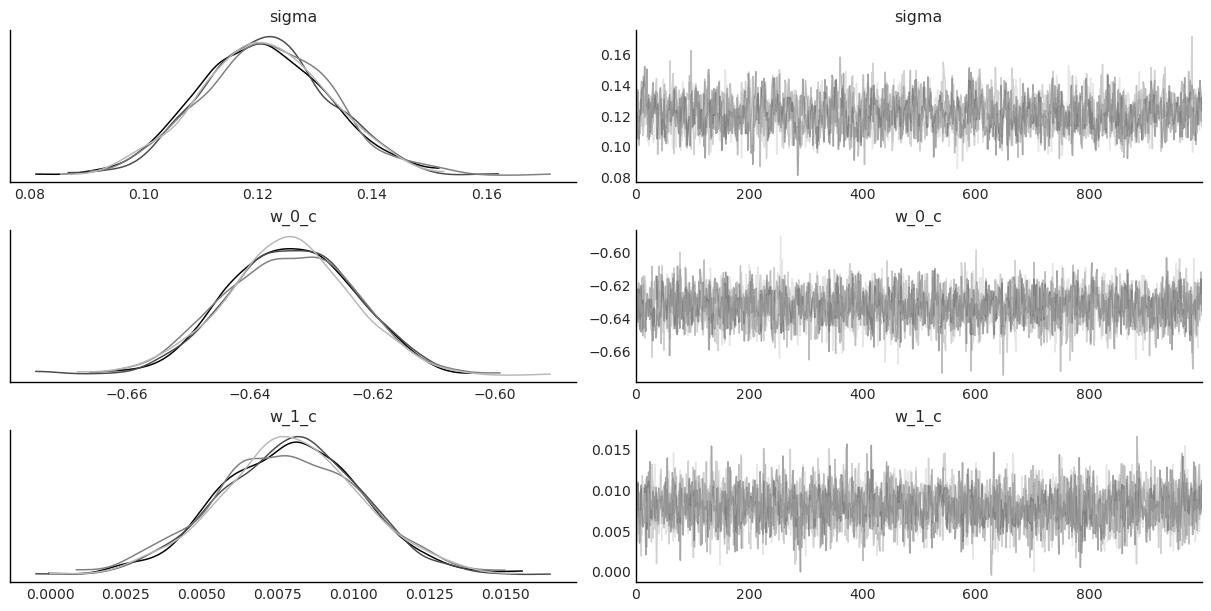

In [17]:
# 非中心化パラメーター化してMCMCを再実行
import pymc as pm
import arviz as az

# データの標本平均
x_mean = x_train.mean()

binomial_glmm_model = pm.Model()
# モデル式を記述
with binomial_glmm_model:
    # 中心化した説明変数x_cと試行数nを観測値として定義
    x_c = pm.Data("x_c", x_train - x_mean, dims="record")
    n = pm.Data("n", n_train, dims="record")
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0_c = pm.Normal("w_0_c", mu=0, sigma=100)  # 中心化後のパラメータであることを明示的に示すため名前変更
    w_1_c = pm.Normal("w_1_c", mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=1.0) # ランダム効果の分散の超事前分布
    # ランダム効果（正規分布）
    z = pm.Normal("z", mu=0, sigma=1, dims="record")  # 非中心化パラメーター
    r = pm.Deterministic("r", z * sigma, dims="record")  # ランダム効果項を非中心化パラメーターから計算
    # 線形予測子（rhoのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    rho = w_0_c + w_1_c*x_c + r
    # リンク関数の逆関数
    # （muのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    mu = pm.math.invlogit(rho)
    # 確率分布（二項分布）
    y = pm.Binomial("y", n=n, p=mu, observed=y_train, dims="record")
# MCMCの実行（学習）
with binomial_glmm_model:
    trace = pm.sample(random_seed=seed)
# 得られた事後分布を表示
trace.posterior

# トレースプロット
az.style.use("arviz-grayscale")
az.plot_trace(trace, combined=False, compact=False, var_names=["sigma", "w_0_c", "w_1_c"])
# 各パラメータのMCMCサンプルの概要を表示
az.summary(trace, round_to=3, var_names=["sigma", "w_0_c", "w_1_c", 'r'])

値が悪かった`sigma`の`ess_bulk`や`r_hat`が大きく改善しています。今回のデータとモデルでは、ニールの漏斗による`sigma`の収束性の悪化が支配的であり、それが非中心化パラメータ化により改善したと推測されます。

## 参考：残差逸脱度とピアソンのカイ二乗統計量

分散パラメータの推定量（不偏推定量）$\hat{\phi}$は、残差逸脱度$D$を自由度$\rm{df}$で割った$\hat{\phi} \simeq \frac{D}{\rm{df}}$、あるいはピアソンのカイ二乗統計量$X^2$を自由度$\rm{df}$で割った$\hat{\phi} \simeq \frac{X^2}{\rm{df}}$として求められました。この$\hat{\phi}$は過分散が発生していなければ1に近づき、過分散の程度が大きいほど大きな値を取るので、過分散の有無の判定に使用できます（前述のように1.5〜2.0を超えたら過分散に対するアクションを打つべきとされており、統計モデリングにおいては個体差によるランダム効果をモデルに含めます）。

ここではこの

- 残差逸脱度$D$
- ピアソンのカイ二乗統計量$X^2$
- 自由度$\rm{df}$

を、具体的にどのように求めるか解説します。

### 残差逸脱度$D$

**残差逸脱度**（residual deviance）とは、評価対象となるデータ（一般的には学習データ）とモデルが与えられたときに、評価対象のモデルの逸脱度と、同種のモデルでの最小の逸脱度との差分を表します。後者の逸脱度を最小とするモデルを**フルモデル**（full model）と呼びます。フルモデルの詳細についてはモデルの種類ごとに後述します。

**逸脱度**（deviance）とは、対数尤度$\log L(\boldsymbol{y} \mid \boldsymbol{X}, \boldsymbol{\theta})$に$-2$を掛けた指標です。対数尤度が「当てはまりの良さ」を表していたことから、逸脱度はその逆の「当てはまりの悪さ」を表します。評価対象のモデルの尤度を$L$、フルモデルの尤度を$L_{\rm{saturated}}$とすると、残差逸脱度$D$は

$D=2(\log L_{\rm{saturated}} - \log L)$

と表せます。

#### 二項ロジスティック回帰モデルの残差逸脱度

フルモデルは、与えられたデータに対して逸脱度が最小となるモデルと表します。これは言い換えると、尤度が最大となるようなモデルを指します。

二項ロジスティック回帰においては、個々のデータの尤度は二項分布の確率質量関数$Bi(y^{(i)} \mid n^{(i)},\mu)$となり、発生率パラメータ$\mu=\frac{y^{(i)}}{n^{(i)}}$のときに最大となります。よってフルモデルは、説明変数$\boldsymbol{x}^{(i)}$が与えられたときに$\mu=\frac{y^{(i)}}{n^{(i)}}$となるようなモデル（$\boldsymbol{x}^{(i)}$に直接$y^{(i)}$を対応づけるモデル）を指し、そのときの尤度は

$L_{\rm{saturated}}=\prod_{i=1}^N Bi(y^{(i)} \mid n^{(i)},\frac{y^{(i)}}{n^{(i)}})$

となり、対数尤度は

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
D
&=
\log L_{\rm{saturated}} \\
&=
\log \prod_{i=1}^N Bi(y^{(i)} \mid n^{(i)},\frac{y^{(i)}}{n^{(i)}}))\\
&=
\sum_{i=1}^N\log \Big(\binom{n^{(i)}}{y^{(i)}} \Big(\frac{y^{(i)}}{n^{(i)}}\Big)^{y^{(i)}} \Big(1-\frac{y^{(i)}}{n^{(i)}}\Big)^{n^{(i)}-y^{(i)}}\Big) \\
&=
\sum_{i=1}^N \Big( \log \binom{n^{(i)}}{y^{(i)}} + y^{(i)}\log \Big(\frac{y^{(i)}}{n^{(i)}}\Big) + (n^{(i)}-y^{(i)}) \log(1-\frac{y^{(i)}}{n^{(i)}})\Big)
\end{align}
" />

となります。

また評価対象のモデルの尤度は、発生率パラメータ$\mu$が線形予測子とリンク関数から説明変数$\boldsymbol{x}$を用いて$\mu^{(i)}=\sigma(\boldsymbol{w}^\top \boldsymbol{x}^{(i)}+w_0)$と表せることをふまえて、

$L = \prod_{i=1}^N Bi(y^{(i)} \mid n^{(i)},\mu^{(i)}) = \prod_{i=1}^N Bi(y^{(i)} \mid n^{(i)},\sigma(\boldsymbol{w}^\top \boldsymbol{x}^{(i)}+w_0))$

となり、対数尤度は

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
D
&=
\log L \\
&=
\log \prod_{i=1}^N Bi(y^{(i)} \mid n^{(i)},\mu^{(i)}))\\
&=
\sum_{i=1}^N\log \Big(\binom{n^{(i)}}{y^{(i)}} (\mu^{(i)})^{y^{(i)}} (1-\mu^{(i)})^{n^{(i)}-y^{(i)}}\Big) \\
&=
\sum_{i=1}^N \Big( \log \binom{n^{(i)}}{y^{(i)}} + y^{(i)}\log (\mu^{(i)}) + (n^{(i)}-y^{(i)}) \log(1-\mu^{(i)})\Big)
\end{align}
" />

となります。

ここから逸脱度は、

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
D
&=
2(\log L_{\rm{saturated}} - \log L) \\
&=
2\sum_{i=1}^N\Big( \Big(\log \binom{n^{(i)}}{y^{(i)}} + y^{(i)}\log \Big(\frac{y^{(i)}}{n^{(i)}}\Big) + (n^{(i)}-y^{(i)}) \log(1-\frac{y^{(i)}}{n^{(i)}}) \Big) - \Big( \log \binom{n^{(i)}}{y^{(i)}} + y^{(i)}\log (\mu^{(i)}) + (n^{(i)}-y^{(i)}) \log(1-\mu^{(i)})\Big) \Big)\\
&=
2\sum_{i=1}^N\Big( y^{(i)}\log \Big(\frac{y^{(i)}/n^{(i)}}{\mu^{(i)}}\Big) + (n^{(i)}-y^{(i)}) \log \Big(\frac{1-y^{(i)}/n^{(i)}}{1-\mu^{(i)}}\Big) \Big)
\end{align}
" />

と求められます。

#### ポアソン回帰モデルの残差逸脱度

観測区間$t$が一定の、以下の式で表されるポアソン回帰モデルを考えます。

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
&\eta=w_1 x+w_0  \nonumber \\
&\log(\mu)=\eta  \nonumber \\
&p(y \mid \boldsymbol{x}, \boldsymbol{w}, w_0) = Po(\mu)
\end{align}
" />

このとき、個々のデータの尤度はポアソン分布の確率質量関数$Po(y^{(i)} \mid \mu)$となり、単位区間あたり平均発生数パラメータ$\mu=y^{(i)}$のときに最大となります。よってフルモデルは、説明変数$\boldsymbol{x}^{(i)}$が与えられたときに$\mu=y^{(i)}$となるようなモデル（$\boldsymbol{x}^{(i)}$に直接$y^{(i)}$を対応づけるモデル）を指し、そのときの尤度は

$L_{\rm{saturated}}=\prod_{i=1}^N Po(y^{(i)} \mid y^{(i)})$

となり、対数尤度は

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
D
&=
\log L_{\rm{saturated}} \\
&=
\log \prod_{i=1}^N Po(y^{(i)} \mid y^{(i)})\\
&=
\sum_{i=1}^N\log \Big(\frac{(y^{(i)})^{y^{(i)}}}{y^{(i)}!} \exp(-y^{(i)}) \Big) \\
&=
\sum_{i=1}^N \Big( y^{(i)}\log y^{(i)} - \log(y^{(i)}!) - y^{(i)} \Big)
\end{align}
" />

となります。

また評価対象のモデルの尤度は、$\mu$が線形予測子とリンク関数から説明変数$\boldsymbol{x}$を用いて$\mu^{(i)}=\exp(\boldsymbol{w}^\top \boldsymbol{x}^{(i)}+w_0)$（$\mu^{(i)}$は最尤推定量$\mu$とは異なるので注意）と表せることをふまえて、

$L = \prod_{i=1}^N Po(y^{(i)} \mid \mu^{(i)}) = \prod_{i=1}^N Po(y^{(i)} \mid \exp(\boldsymbol{w}^\top \boldsymbol{x}^{(i)}+w_0))$

となり、対数尤度は

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
D
&=
\log L_{\rm{saturated}} \\
&=
\log \prod_{i=1}^N Po(y^{(i)} \mid \mu^{(i)}))\\
&=
\sum_{i=1}^N\log \Big(\frac{(\mu^{(i)})^{y^{(i)}}}{y^{(i)}!} \exp(-\mu^{(i)}) \Big) \\
&=
\sum_{i=1}^N \Big( y^{(i)}\log \mu^{(i)} - \log(y^{(i)}!) - \mu^{(i)} \Big)
\end{align}
" />

となります。

ここから逸脱度は、

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
D
&=
2(\log L_{\rm{saturated}} - \log L) \\
&=
2\sum_{i=1}^N\Big( \Big( y^{(i)}\log y^{(i)} - \log(y^{(i)}!) - y^{(i)} \Big) + \Big( y^{(i)}\log \mu^{(i)} - \log(y^{(i)}!) - \mu^{(i)} \Big) \Big)\\
&=
2\sum_{i=1}^N\Big( y^{(i)}\log \Big(\frac{y^{(i)}}{\mu^{(i)}}\Big) - \big(y^{(i)} - \mu^{(i)}\big) \Big)
\end{align}
" />

と求められます。

### ピアソンのカイ二乗統計量$X^2$

GLMにおけるピアソンのカイ二乗統計量$X^2$は、以下のように定義されます。

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
X^2 = \sum_{i=1}^N \frac{(y^{(i)} - \hat{\mu}^{(i)})^2}{V[\hat{\mu}^{(i)}]}
\end{align}
" />

分子の$y^{(i)}$は応答変数の実測値、$\hat{\mu}^{(i)}$はモデルが予測した応答変数の平均値を表します。$\hat{\mu}^{(i)}$は一般的には説明変数から線形予測子とリンク関数$f(\psi)$で求められる確率分布パラメータ$\mu^{(i)}=f^{-1}(\boldsymbol{w}^\top \boldsymbol{x}^{(i)}+w_0)$と等しくなりますが、二項分布の場合は試行数をかけた$\hat{\mu}^{(i)}=n^{(i)}\mu^{(i)}=n^{(i)}f^{-1}(\boldsymbol{w}^\top \boldsymbol{x}^{(i)}+w_0)$となることに注意してください。

分母の$V[\hat{\mu}^{(i)}]$は、分散パラメータの説明でも登場した、説明変数から求められる応答変数の確率分布の理論上の分散で、二項分布では$n^{(i)}\mu^{(i)}(1-\mu^{(i)})$、ポアソン分布では$\mu^{(i)}$となります。

以上まとめると$X^2$は「理論分散で標準化された応答変数の残差の二乗和」と解釈でき、データ全体での分散の大きさを理論値で標準化したものとみなせます。

### 自由度$\rm{df}$

統計学における**自由度**$\rm{df}$（degree of freedom）とは、独立して変化できる値の数を表しています。統計モデリングにおいて自由度は、**残差自由度**（residual degrees of freedom）とも呼ばれ、データの独立な観測数（一般的にはサンプルサイズ$N$）から、モデルのパラメータの数$k$を引いたものを表します。

$\rm{df}=N​−k$

直感的にはパラメータの値を1つ求めるために自由に動けるデータの数が1つ減るので、その分自由度が減っていくイメージです。例えば正規分布の平均パラメータの値が決まっているとき、$N-1$個のデータの値を自由に決めたとき、残りの1つのデータの値は自動的に決まります。

## 参考：過分散していないデータに個体差によるランダム効果を適用した場合の挙動

ランダム効果項を含む二項ロジスティック回帰は、モデル式を見るとランダム効果項を持たない通常の二項ロジスティック回帰を内包（ネスト）しているように見えます。
よって直感的には、ランダム効果項を含めてたモデルを常に使えば、過分散がある場合・ない場合両方をカバーできて便利に見えます。

しかし実際には、ランダム効果項を含むモデルを過分散していないデータに適用すると、MCMCが収束しません。よって「B. 過分散の判定」にもとづき事前に過分散の有無を判定し、過分散がありそうな場合はランダム効果項を含め、過分散がなさそうな場合はランダム効果項を含めないようモデルを使い分けることが望ましいです。このように過分散していないデータでランダム効果項を含むモデルのMCMCが収束しない様子を、合成データを用いたシミュレーションで確認してみましょう。

ランダム効果項を含む二項ロジスティック回帰モデルの式に基づきデータを生成するシミュレーションを以下のように実装します。ハイパーパラメータ$\sigma_r$（ランダム効果項の正規分布の標準偏差）を変更することで過分散の大きさを制御します。

/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_27917/2832076492.py:29: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


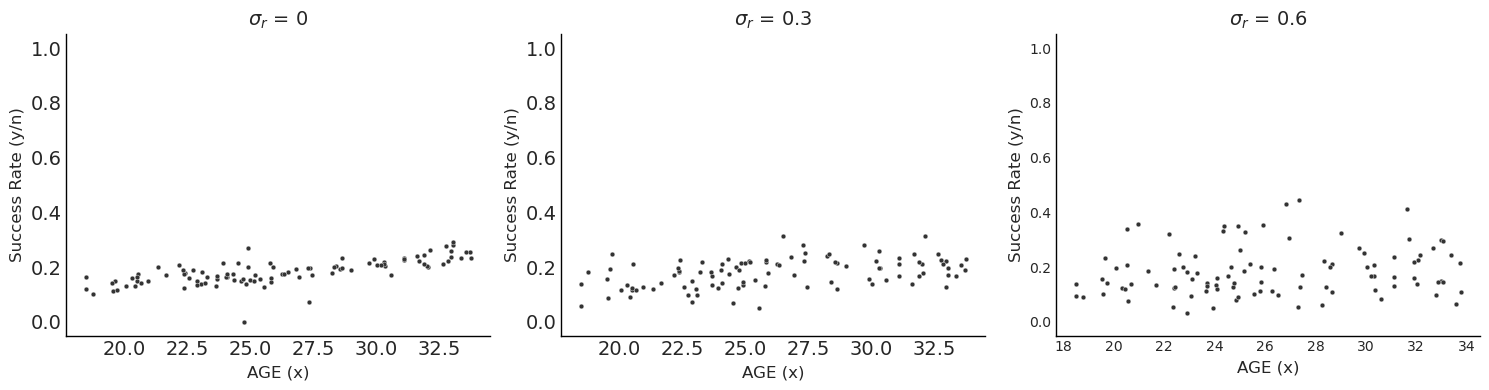

In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# データの生成
X_MEAN = 26  # 説明変数xの平均値
x_train = np.random.uniform(X_MEAN - 8, X_MEAN + 8, size=100)  # 説明変数xのデータ（26±8の間でランダムに生成）
n_train = np.random.randint(20, 600, size=100)  # 試行数nのデータ（20から600までの間でランダムに生成）
W_1 = 0.05  # 真の傾きパラメータ
W_0 = -2.8  # 真の切片パラメータ
SIGMA_O = [0, 0.3, 0.6]  # ハイパーパラメータσ_r（ランダム効果項の正規分布の標準偏差）

# プロットの設定
fig, axes = plt.subplots(nrows=1, ncols=len(SIGMA_O), figsize=(5*len(SIGMA_O), 4))

for i, sigma_o in enumerate(SIGMA_O):
    # 過分散を考慮した成功確率の生成
    r_train = np.random.normal(loc=0, scale=sigma_o, size=100)  # ランダム効果項
    mu_train = 1/(1+np.exp(-(W_0 + W_1*x_train + r_train)))  # 成功確率（説明変数の線形結合＋ランダム効果項をロジスティック変換）
    y_train = np.random.binomial(n=n_train, p=mu_train, size=100)
    x_train_c = x_train - X_MEAN  # 説明変数xの中心化
    # データを散布図でプロット
    sns.scatterplot(x=x_train, y=y_train/n_train, s=12, color='#333333', ax=axes[i])
    axes[i].set_xlabel('AGE (x)', fontsize=12)
    axes[i].set_ylabel('Success Rate (y/n)', fontsize=12)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].set_title(fr'$\sigma_r$ = {sigma_o}', fontsize=14) # tex形式でタイトルを設定
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()

$\sigma_r=0$のときは二項分布由来のばらつきのみであるのに対し、$\sigma_r$が大きくなるにつれてランダム効果項由来のばらつき（過分散）が追加されていきます。

# 過分散ありデータに対するランダム効果付き二項ロジスティック回帰モデルの適用

最初に過分散があるデータに対してランダム効果付き二項ロジスティック回帰モデルのMCMCを実行してみます。ここでは収束性向上のために中心化を実施しています。

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_0_c, w_1_c, sigma, r]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w_0_c,-1.441,0.036,-1.508,-1.375,0.001,0.001,1606.970,2234.754,1.002
w_1_c,0.049,0.008,0.034,0.065,0.000,0.000,1303.854,2085.654,1.000
r[0],-0.319,0.155,-0.630,-0.046,0.002,0.003,5003.433,3015.005,1.004
r[1],0.082,0.112,-0.131,0.284,0.002,0.002,4354.111,2723.258,1.001
r[2],0.199,0.147,-0.092,0.459,0.002,0.003,4287.892,2781.512,1.001
...,...,...,...,...,...,...,...,...,...
r[96],0.371,0.140,0.101,0.631,0.002,0.002,3867.123,2763.102,1.000
r[97],-0.667,0.187,-1.037,-0.346,0.003,0.003,4640.976,3007.576,1.001
r[98],-0.453,0.151,-0.743,-0.178,0.002,0.003,4296.096,2782.006,1.002
r[99],-0.066,0.123,-0.303,0.165,0.002,0.002,3122.777,2841.201,1.001


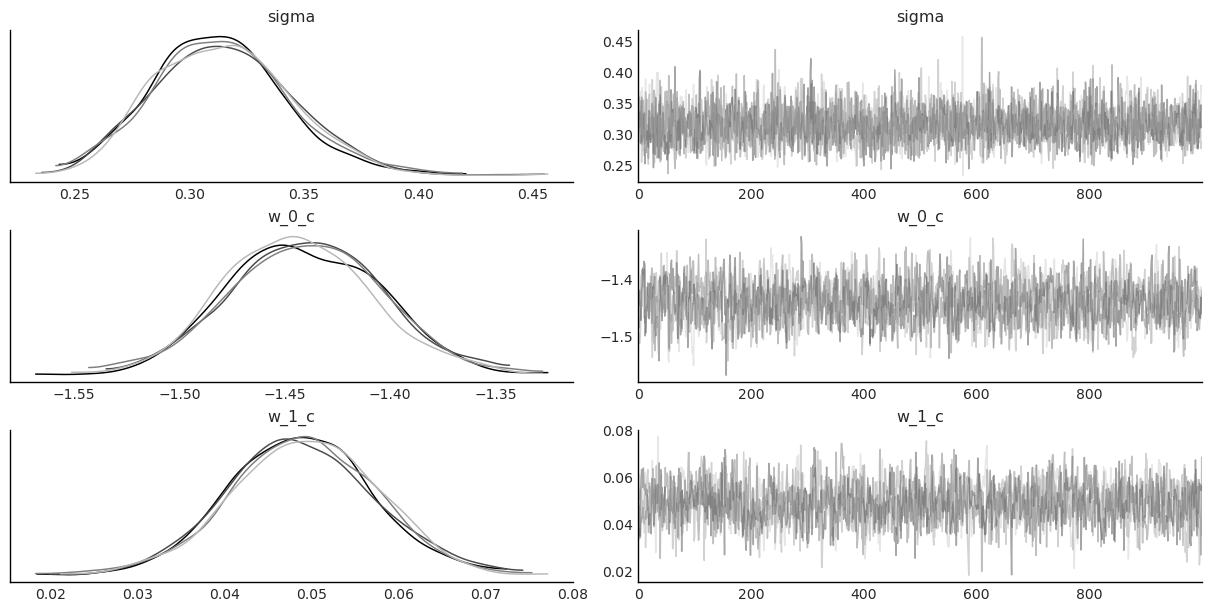

In [19]:
# 過分散ありデータに対するランダム効果付き二項ロジスティック回帰モデルの適用
import pymc as pm
import arviz as az

seed=42  # 乱数シードを指定（結果の再現性を担保）
SIGMA_O = 0.3  # 過分散の標準偏差
# 過分散を考慮した成功確率の生成
r_train = np.random.normal(loc=0, scale=SIGMA_O, size=100)  # ランダム効果項
mu_train = 1/(1+np.exp(-(W_0 + W_1*x_train + r_train)))  # 成功確率（説明変数の線形結合＋ランダム効果項をロジスティック変換）
y_train = np.random.binomial(n=n_train, p=mu_train, size=100)
x_train_c = x_train - X_MEAN  # 説明変数xの中心化

# モデル定義用のインスタンスを作成
binomial_glmm_model = pm.Model()
# モデル式を記述
with binomial_glmm_model:
    # 中心化した説明変数x_cと試行数nを観測値として定義
    x_c = pm.Data("x_c", x_train_c, dims="record")
    n = pm.Data("n", n_train, dims="record")
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0_c = pm.Normal("w_0_c", mu=0, sigma=100)  # 中心化後のパラメータであることを明示的に示すため名前変更
    w_1_c = pm.Normal("w_1_c", mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=1.0) # ランダム効果の分散の超事前分布
    # ランダム効果（正規分布）
    r = pm.Normal("r", mu=0, sigma=sigma, dims="record")
    # 線形予測子（rhoのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    rho = w_0_c + w_1_c*x_c + r  # 中心化した説明変数を渡す
    # リンク関数の逆関数
    # （muのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    mu = pm.math.invlogit(rho)
    # 確率分布
    y = pm.Binomial("y", n=n, p=mu, observed=y_train, dims="record")

# MCMCの実行（学習）
with binomial_glmm_model:
    trace = pm.sample(random_seed=seed)
# 得られた事後分布を表示
trace.posterior

# トレースプロット
az.style.use("arviz-grayscale")
az.plot_trace(trace, var_names=['sigma', 'w_0_c', 'w_1_c'], combined=False, compact=False)
# 各パラメータのMCMCサンプルの概要を表示
az.summary(trace, round_to=3)

事後分布やトレースプロットの形状が安定しており、`ess_bulk`や`r_hat`のような収束を示す指標も良好な値となっていることから、収束しているとみなせそうです。

# 過分散なしデータに対するランダム効果付き二項ロジスティック回帰モデルの適用

つづいて、過分散がほとんど発生していないデータに対して個体差によるランダム効果を含む二項ロジスティック回帰モデルのMCMCを実施してみます。
過分散がほとんどない状態を模擬するため、データ生成時の過分散の標準偏差$\sigma_r$に非常に小さな値、例えば0.01を指定します。

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_0_c, w_1_c, sigma, r]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
There were 654 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w_0_c,-1.499,0.014,-1.528,-1.472,0.001,0.001,354.300,350.276,1.050
w_1_c,0.052,0.003,0.046,0.058,0.000,0.000,881.448,910.566,1.093
r[0],0.004,0.029,-0.044,0.072,0.001,0.006,998.907,150.783,1.313
r[1],0.001,0.025,-0.046,0.052,0.001,0.005,1480.687,106.829,1.229
r[2],0.005,0.028,-0.049,0.060,0.001,0.006,1197.451,92.920,1.356
...,...,...,...,...,...,...,...,...,...
r[96],-0.006,0.028,-0.067,0.042,0.002,0.005,346.263,109.461,1.268
r[97],0.005,0.028,-0.046,0.061,0.001,0.005,1297.552,137.173,1.374
r[98],-0.007,0.030,-0.075,0.045,0.003,0.006,389.862,81.792,1.272
r[99],0.004,0.025,-0.043,0.054,0.001,0.005,1193.563,113.614,1.323


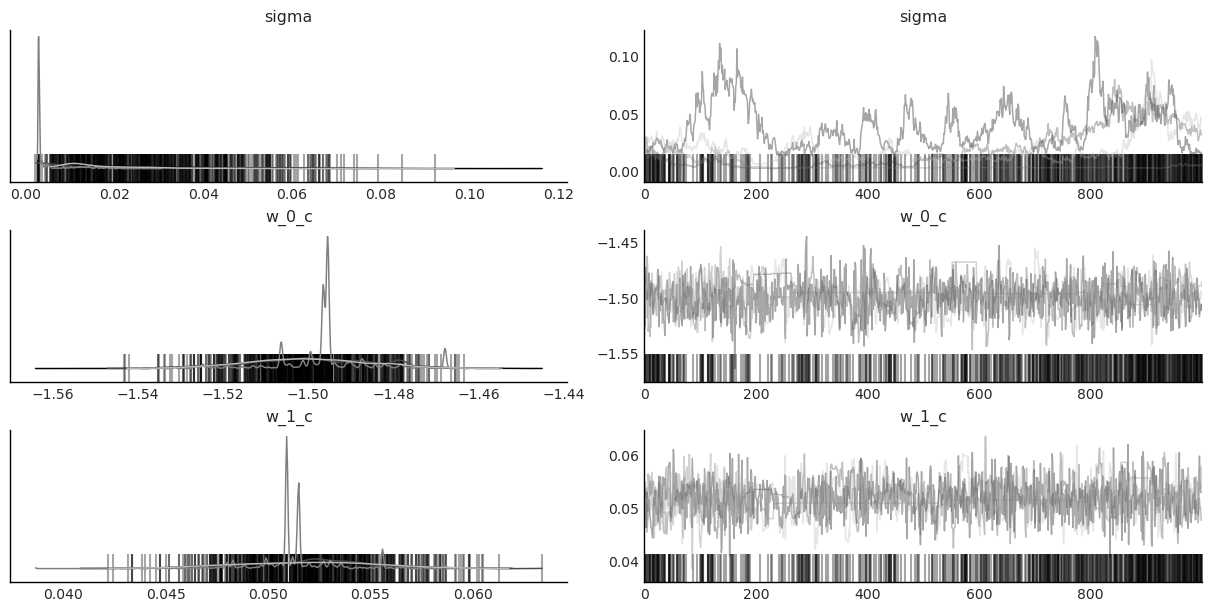

In [20]:
# 過分散が小さいデータに対するランダム効果付き二項ロジスティック回帰モデルの構築と学習
SIGMA_O = 0.01  # 過分散の標準偏差（非常に小さな値を指定）
# 過分散を考慮した成功確率の生成
r_train = np.random.normal(loc=0, scale=SIGMA_O, size=100)  # ランダム効果項
mu_train = 1/(1+np.exp(-(W_0 + W_1*x_train + r_train)))  # 成功確率（説明変数の線形結合＋ランダム効果項をロジスティック変換）
y_train = np.random.binomial(n=n_train, p=mu_train, size=100)
x_train_c = x_train - X_MEAN  # 説明変数xの中心化

# モデル定義用のインスタンスを作成
binomial_glmm_model = pm.Model()
# モデル式を記述
with binomial_glmm_model:
    # 中心化した説明変数x_cと試行数nを観測値として定義
    x_c = pm.Data("x_c", x_train_c, dims="record")
    n = pm.Data("n", n_train, dims="record")
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0_c = pm.Normal("w_0_c", mu=0, sigma=100)  # 中心化後のパラメータであることを明示的に示すため名前変更
    w_1_c = pm.Normal("w_1_c", mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=1.0) # ランダム効果の分散の超事前分布
    # ランダム効果（正規分布）
    r = pm.Normal("r", mu=0, sigma=sigma, dims="record")
    # 線形予測子（rhoのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    rho = w_0_c + w_1_c*x_c + r  # 中心化した説明変数を渡す
    # リンク関数の逆関数
    # （muのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    mu = pm.math.invlogit(rho)
    # 確率分布
    y = pm.Binomial("y", n=n, p=mu, observed=y_train, dims="record")

# MCMCの実行（学習）
with binomial_glmm_model:
    trace = pm.sample(random_seed=seed)
# 得られた事後分布を表示
trace.posterior

# トレースプロット
az.style.use("arviz-grayscale")
az.plot_trace(trace, var_names=['sigma', 'w_0_c', 'w_1_c'], combined=False, compact=False)
# 各パラメータのMCMCサンプルの概要を表示
az.summary(trace, round_to=3)

MCMCサンプルが収束しておらず、特にランダム効果項のパラメータ`sigma`の収束性が極めて悪くなっていることが分かります。

これは、データの過分散が小さい場合はランダム効果項の標準偏差パラメータの真値がほぼ0になりますが、このパラメータには正値になるという制約を課しているため、両者の関係に矛盾が生じてMCMCのサンプリングがうまく進まないことに起因しています。

このように、過分散が発生していない、あるいは過分散が非常に小さいデータにランダム効果項を含む二項ロジスティック回帰を適用すると、MCMCのサンプリングがうまく進まないことが分かりました。冒頭で挙げた直感は成り立たず、ランダム効果項を含むモデルが万能ではないことが分かります。このことから、**過分散を事前に確認し、小さい場合はランダム効果項を含まないモデルを、大きい場合はランダム効果項を含むモデルを採用**すべきと言えるでしょう。